In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import clear_output

def plot2d(x, y, p):
    fig = plt.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(projection='3d')
    X, Y = np.meshgrid(x, y)
    ax.plot_surface(X, Y, p[:], rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.view_init(30, 225)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

def poission2d(p, b, dx, dy, nt):
    for _ in range(nt):
        pn = p.copy()

        p[1:-1, 1:-1] = (
            (dy**2 * (pn[1:-1, 2:] + pn[1:-1, :-2]) + dx**2 * (pn[2:, 1:-1] + pn[:-2, 1:-1]))
            / (2 * (dx**2 + dy**2))
            - (b[1:-1, 1:-1] / 2)
        )

        p[0, :] = 0
        p[-1, :] = 0
        p[:, 0] = 0
        p[:, -1] = 0

    return p

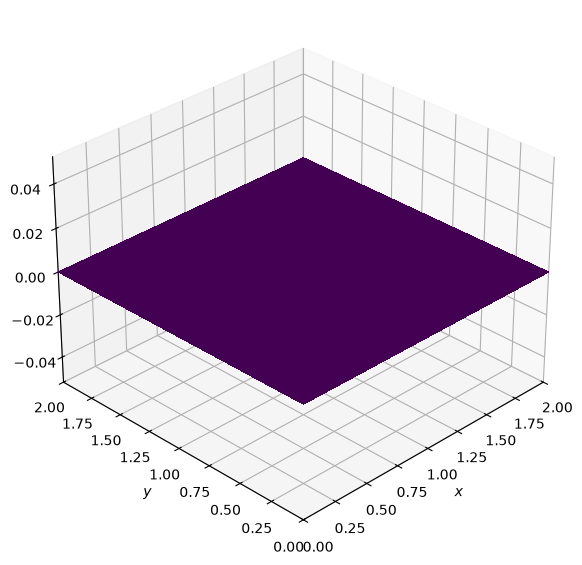

In [2]:
nx = 50
ny = 50
nt = 100

dx = 2 / (nx - 1)
dy = 2 / (ny - 1)

p = np.zeros((ny, nx))
b  = np.zeros((ny, nx))

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

b[int(0.25 * ny), int(0.25 * nx)]  = 100
b[int(0.75 * ny), int(0.75 * nx)] = -100

plot2d(x, y, p)

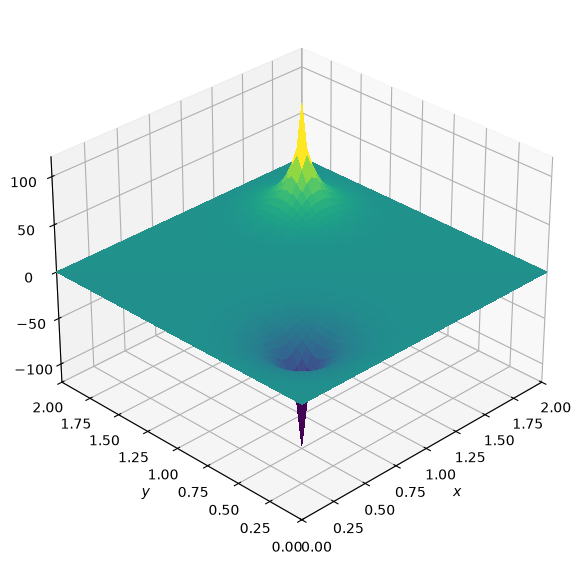

In [3]:
p = poission2d(p, b, dx, dy, nt)
plot2d(x, y, p)